In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
print("Libraries loaded ✅")

Libraries loaded ✅


In [ ]:
data = {
    'sqft': [800, 1000, 1200, 1500, 900, 1100, 1300, 5000],
    'bedrooms': [1, 2, 2, 3, 1, 2, 3, 10],
    'age': [5, 10, 2, 15, 8, 12, 3, 1],
    'price': [40, 55, 65, 85, 45, 60, 70, 500]
}
df = pd.DataFrame(data)
print("=== df.head() ===")
print(df.head())
print("\n=== df.info() ===")
print(df.info())
print("\n=== df.describe() ===")
print(df.describe())

=== df.head() ===
   sqft  bedrooms  age  price
0   800         1    5     40
1  1000         2   10     55
2  1200         2    2     65
3  1500         3   15     85
4   900         1    8     45

=== df.info() ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8 entries, 0 to 7
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   sqft      8 non-null      int64
 1   bedrooms  8 non-null      int64
 2   age       8 non-null      int64
 3   price     8 non-null      int64
dtypes: int64(4)
memory usage: 388.0 bytes
None

=== df.describe() ===
              sqft  bedrooms        age       price
count     8.000000    8.0000   8.000000    8.000000
mean   1600.000000    3.0000   7.000000  115.000000
std    1391.812795    2.9277   5.070926  156.204994
min     800.000000    1.0000   1.000000   40.000000
25%     975.000000    1.7500   2.750000   52.500000
50%    1150.000000    2.0000   6.500000   62.500000
75%    1350.000000    3.00

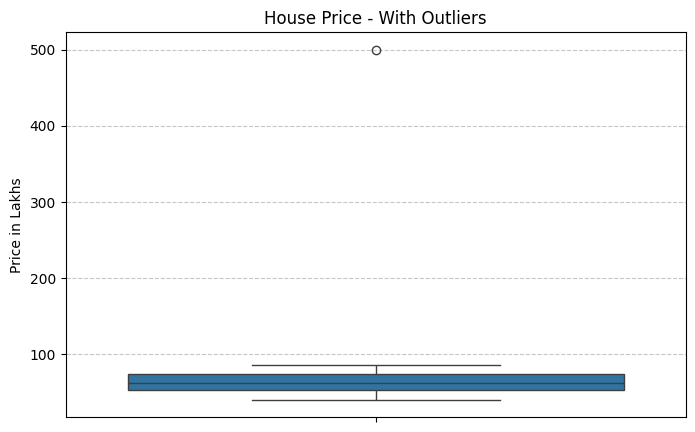

In [ ]:
plt.figure(figsize=(8,5))
sns.boxplot(y=df['price'])
plt.title('House Price - With Outliers')
plt.ylabel('Price in Lakhs')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [ ]:
Q1 = df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
print(f"Lower bound: {lower_bound}")
print(f"Upper bound: {upper_bound}")
df_clean = df[(df['price'] >= lower_bound) & (df['price'] <= upper_bound)]
print(f"\nBefore: {len(df)} rows")
print(f"After: {len(df_clean)} rows")
print(df_clean)

Lower bound: 20.625
Upper bound: 105.625

Before: 8 rows
After: 7 rows
   sqft  bedrooms  age  price
0   800         1    5     40
1  1000         2   10     55
2  1200         2    2     65
3  1500         3   15     85
4   900         1    8     45
5  1100         2   12     60
6  1300         3    3     70


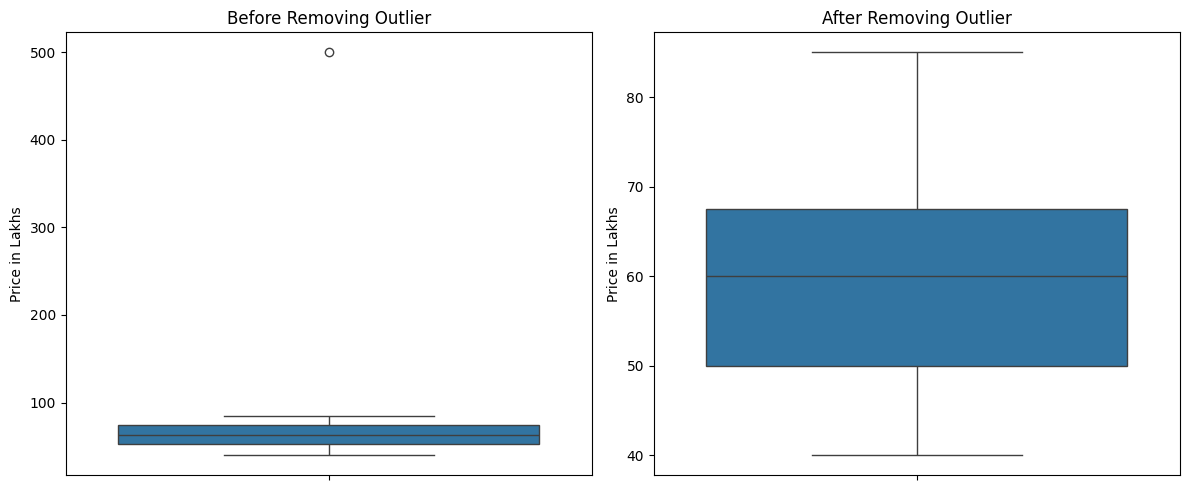

Clean Data Stats:
count     7.000000
mean     60.000000
std      15.275252
min      40.000000
25%      50.000000
50%      60.000000
75%      67.500000
max      85.000000
Name: price, dtype: float64


In [ ]:
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
sns.boxplot(y=df['price'])
plt.title('Before Removing Outlier')
plt.ylabel('Price in Lakhs')
plt.subplot(1,2,2)
sns.boxplot(y=df_clean['price'])
plt.title('After Removing Outlier')
plt.ylabel('Price in Lakhs')
plt.tight_layout()
plt.show()
print("Clean Data Stats:")
print(df_clean['price'].describe())

In [ ]:
X = df_clean[['sqft']]
y = df_clean['price']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print("R2 Score:", round(r2_score(y_test, y_pred), 3))
print("RMSE:", round(np.sqrt(mean_squared_error(y_test, y_pred)), 2))
test_sqft = 1200
predicted_price = model.predict([[test_sqft]])
print(f"\n{test_sqft} sqft veedu estimated price: {predicted_price[0]:.2f} Lakhs")

R2 Score: 0.907
RMSE: 2.59

1200 sqft veedu estimated price: 64.60 Lakhs


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


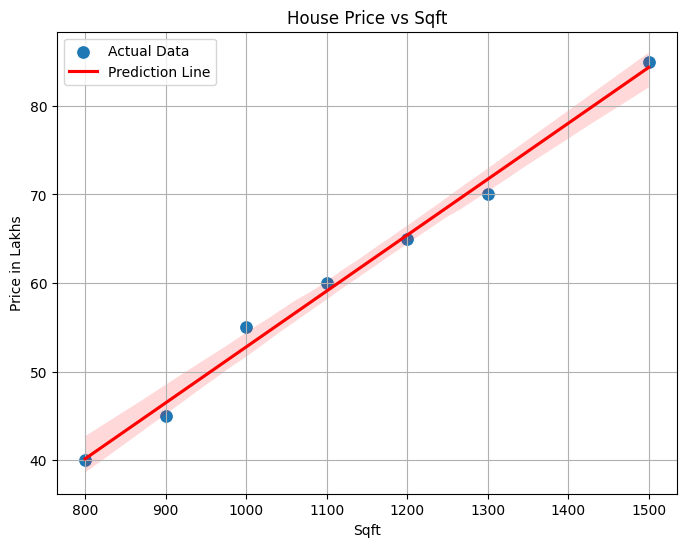

In [ ]:
plt.figure(figsize=(8,6))
sns.scatterplot(x=df_clean['sqft'], y=df_clean['price'], s=100, label='Actual Data')
sns.regplot(x=df_clean['sqft'], y=df_clean['price'], scatter=False, color='red', label='Prediction Line')
plt.title('House Price vs Sqft')
plt.xlabel('Sqft')
plt.ylabel('Price in Lakhs')
plt.legend()
plt.grid()
plt.show()

In [ ]:
X = df_clean[['sqft', 'bedrooms', 'age']]
model_multi = LinearRegression()
model_multi.fit(X, y)
print("Multi-feature R2:", model_multi.score(X, y))

Multi-feature R2: 0.9958711111500824


In [ ]:
new_house = [[1100, 3, 5]]
pred = model_multi.predict(new_house)
print("Predicted Price:", pred[0], "Lakhs")

Predicted Price: 60.088080039283085 Lakhs


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
